# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Fasiuu/FLYRANK_TASK1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
# Setup — shared feature builder from this repo + DuckDB connection to the hosted release.
# Token: Colab Secret HF_TOKEN (preferred) or a getpass prompt. Never paste a token into a cell.
%pip -q install duckdb
import os, sys, subprocess, json, warnings
warnings.filterwarnings('ignore')
if not os.path.exists('FLYRANK_TASK1'):
    subprocess.run(['git', 'clone', '-q', '--depth', '1', 'https://github.com/Fasiuu/FLYRANK_TASK1.git'], check=True)
sys.path.insert(0, 'FLYRANK_TASK1/work/scripts')
import numpy as np, pandas as pd
import flyrank_features as ff
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
np.random.seed(ff.SEED)
con = ff.connect()
os.makedirs('work/outputs', exist_ok=True)
print('connected; seed =', ff.SEED)

Hugging Face READ token (hf_...): ··········
connected; seed = 42


## 1. Question

*The research question and the decision it supports.*

**Question:** using only what's known on decision day, which pages on a site should a reviewer open first, because next month their Google impressions are likely to fall more than 20% further than the site as a whole?

**Decision it supports:** the order in which a content/SEO reviewer spends a limited monthly review slot. A false alarm costs a wasted review. A miss costs weeks of lost visibility before a dashboard shows it. That's why the evaluation focuses on the top of each site's queue.

In [2]:
question = ('Using only what is known on decision day, which pages on a site should a reviewer check first, '
            'because next month their Google search impressions are likely to fall more than 20% further than the site as a whole?')
print(question)

Using only what is known on decision day, which pages on a site should a reviewer check first, because next month their Google search impressions are likely to fall more than 20% further than the site as a whole?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** `FlyRank/internship-warehouse`, build `flyrank_pseudonymized_warehouse_release_v20260703` (gated Hugging Face dataset, read in place with DuckDB).

**Tables:** `fact_content_daily_performance` (78.8M daily rows; I read December 2025-June 2026), `dim_content` (creation date, word count, keyword volume), `dim_clients` (GSC feed start).

**Windows:** four decision dates, the last day of March, April, May and June 2026. Features come from the 90 days before each date, the outcome from the 30 days after. March and April are development. **May-end → June outcome is the sealed test.** June-end is the live queue (no outcome yet).

**Excluded:** the query table (its window overlaps the outcome months), export-time edit dates (future information), GA4 and AI sessions (too short / too sparse), every ID as a feature, and all product decision fields. Everything shown is aggregated or pseudonymised.

In [3]:
# Build the per-item panel for all decision dates incl. the sealed one and the deploy date (one scan).
import time
t0 = time.time()
panel = ff.build_panel(con, ff.ALL_DATES + [ff.DEPLOY_DATE])
panel['decision_date'] = pd.to_datetime(panel['decision_date']).dt.strftime('%Y-%m-%d')
m = ff.model_frame(panel)
lab = m[m.decision_date != ff.DEPLOY_DATE].copy()      # rows with an observed outcome month
dep = m[m.decision_date == ff.DEPLOY_DATE].copy()      # today's queue: the label month is the real future
print(f'{len(panel):,} item-date rows in {time.time()-t0:.0f}s; labelled rows {len(lab):,}; deploy rows {len(dep):,}')
print(lab.groupby('decision_date').agg(rows=('declined', 'size'), clients=('client_hash_id', 'nunique'),
      site_relative_rate=('declined', 'mean'), plain_drop_rate=('declined_abs', 'mean'), median_site_ratio=('client_ratio', 'median')).round(3).to_string())
print(f'deploy snapshot {ff.DEPLOY_DATE}: {len(dep):,} pages, {dep.client_hash_id.nunique()} sites')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

433,772 item-date rows in 168s; labelled rows 219,935; deploy rows 87,664
                rows  clients  site_relative_rate  plain_drop_rate  median_site_ratio
decision_date                                                                        
2026-03-31     63460       25               0.493            0.519              0.894
2026-04-30     71297       27               0.485            0.637              0.737
2026-05-31     85178       37               0.519            0.747              0.642
deploy snapshot 2026-06-30: 87,664 pages, 39 sites


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Population:** pages with ≥200 impressions in the 60 days before T, at least 90 days old, from clients whose GSC feed covers the full feature window.

**Label (observed, site-relative):** declined = the page's next-30-day impressions relative to its own prior 60-day monthly average are more than 20% *below* the same ratio for its whole site. The plain ">20% drop" label was rejected because its rate drifted from 52% to 75% with site-wide swings.

**Features (18):** impressions in three 30-day blocks (log), two momentum ratios, clicks and CTR, impression-weighted position, its change and daily volatility, days visible, one-day-spike share, weekend share, page age, word count and keyword volume with missing-data flags.

**Baseline:** a frozen five-sign rule (sliding impressions, slipping position, one-day spike, age over 270 days, patchy visibility) with reason codes.

**Validation:** client-grouped *and* time-forward. Clients are hashed into 4 fixed folds, and each fold is scored by a model trained only on the other folds' *earlier* snapshots. The model choice was frozen on the development split before June was opened.

**Leakage checks:** an outcome-month feature (harness test), an export-time edit flag, the query-table overlap, a label-sibling scan, and the population filter, all in w03/w06.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
MAKERS = {
    'logreg': lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    'hgb': lambda: HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_leaf_nodes=31,
                                                  min_samples_leaf=100, random_state=ff.SEED),
    'rf': lambda: RandomForestClassifier(n_estimators=300, min_samples_leaf=50, n_jobs=-1, random_state=ff.SEED),
}
FINAL = 'hgb'    # frozen in w05 on the development split (best top-of-queue precision), never re-chosen later
F = ff.FEATURES

def baseline(df):
    """Frozen transparent rule: one point per warning sign, ties broken by current visibility."""
    r = pd.DataFrame(index=df.index)
    r['sliding_impressions'] = df.imp_last30 < 0.85 * df.imp_prev30      # already losing impressions
    r['position_slipping']   = df.pos_change > 1.0                        # average rank got >1 place worse
    r['one_day_spike']       = df.spike_share > 0.25                      # month propped up by a single day
    r['aging_page']          = df.content_age_days > 270                  # past the decay cliff in FlyRank's paper
    r['patchy_visibility']   = df.days_with_imp_last30 < 15               # visible on fewer than half the days
    points = r.sum(axis=1)
    score = points + df.log_imp_last30 / 100.0
    reasons = r.apply(lambda row: '|'.join(c for c in r.columns if row[c]) or 'none', axis=1)
    return score, reasons, r

from sklearn.metrics import roc_auc_score, average_precision_score
def evaluate(scores, y, ks=(20, 50, 100, 500)):
    y = np.asarray(y).astype(int)
    d = {'base_rate': round(float(y.mean()), 4), 'auc': round(float(roc_auc_score(y, scores)), 4),
         'ap': round(float(average_precision_score(y, scores)), 4)}
    for k in ks:
        d[f'p@{k}'] = round(ff.precision_at_k(scores, y, k), 4)
    return d
def client_queue_at_10(df, scores, min_items=30):
    """How a single site would use it: precision of its OWN top-10, averaged over clients
    (with those clients' average base rate next to it)."""
    tmp = df[['client_hash_id', 'declined']].copy(); tmp['s'] = np.asarray(scores)
    rows = [(g.sort_values('s', ascending=False).declined.head(10).mean(), g.declined.mean())
            for _, g in tmp.groupby('client_hash_id') if len(g) >= min_items]
    return {'client_p@10': round(float(np.mean([a for a, b in rows])), 3),
            'client_base': round(float(np.mean([b for a, b in rows])), 3), 'clients': len(rows)}
print('features:', F)
print('label: page_ratio < 0.8 x client_ratio over (T, T+30]; population: >=', ff.MIN_IMP_60D, 'impressions in (T-60, T], page age >=', ff.MIN_AGE_DAYS, 'days, client feed covers (T-90, T]')

features: ['log_imp_last30', 'log_imp_prev30', 'log_imp_prev60_90', 'imp_momentum', 'imp_momentum_long', 'log_clicks_last30', 'ctr_last30', 'pos_last30', 'pos_change', 'pos_volatility', 'days_with_imp_last30', 'spike_share', 'weekend_share', 'content_age_days', 'log_word_count', 'has_word_count', 'log_search_volume', 'has_keyword_data']
label: page_ratio < 0.8 x client_ratio over (T, T+30]; population: >= 200 impressions in (T-60, T], page age >= 90 days, client feed covers (T-90, T]


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Same rows, same split, same metrics. Base rate on the sealed month ≈ 0.52.

| | ROC-AUC | avg precision | precision@50 | precision@500 | per-site top-10 precision |
|---|---|---|---|---|---|
| random queue | 0.500 | ≈0.52 | ≈0.52 | ≈0.52 | 0.52 |
| rule baseline | 0.602 | 0.605 | 0.86 | 0.83 | 0.75 |
| logistic regression | 0.701 | 0.710 | 0.96 | 0.95 | 0.91 |
| **gradient boosting (final)** | **0.702** | **0.713** | **0.98** | **0.96** | **0.89** |

The development month told the same story (AUC 0.731 vs 0.614), so the June result isn't a one-off. The pooled precision@50 is high for every method because a few big sites dominate a pooled list. The per-site top-10 and AUC are the numbers that separate the methods.

In [5]:
T1, T2 = ff.DEV_DATES; T3 = ff.SEALED_DATE
out, curves = {}, {}
for split, train_dates, test_date in [('dev', [T1], T2), ('sealed', [T1, T2], T3)]:
    o_final = ff.grouped_forward_scores(lab, train_dates, test_date, MAKERS[FINAL], F)
    o_lr = ff.grouped_forward_scores(lab, train_dates, test_date, MAKERS['logreg'], F)
    b, _, _ = baseline(o_final)
    out[split] = {'baseline_rule': {**evaluate(b, o_final.declined), **client_queue_at_10(o_final, b)},
                  'logreg': {**evaluate(o_lr.score, o_lr.declined), **client_queue_at_10(o_lr, o_lr.score)},
                  FINAL: {**evaluate(o_final.score, o_final.declined), **client_queue_at_10(o_final, o_final.score)}}
    if split == 'sealed':
        ks = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
        y = o_final.declined.astype(int).values
        curves = {'k': ks, 'base_rate': float(y.mean()),
                  'baseline_rule': [ff.precision_at_k(b.values, y, k) for k in ks],
                  'logreg': [ff.precision_at_k(o_lr.score.values, y, k) for k in ks],
                  FINAL: [ff.precision_at_k(o_final.score.values, y, k) for k in ks]}
        sealed_frame = o_final
for split in out:
    print(f'== {split} =='); print(pd.DataFrame(out[split]).T.to_string())

== dev ==
               base_rate     auc      ap  p@20  p@50  p@100  p@500  client_p@10  client_base  clients
baseline_rule     0.4847  0.6139  0.5848  0.90  0.86   0.89  0.884        0.811        0.498     19.0
logreg            0.4847  0.6961  0.6851  0.85  0.90   0.89  0.902        0.905        0.498     19.0
hgb               0.4847  0.7311  0.7202  0.95  0.96   0.98  0.940        0.858        0.498     19.0
== sealed ==
               base_rate     auc      ap  p@20  p@50  p@100  p@500  client_p@10  client_base  clients
baseline_rule     0.5186  0.6016  0.6054  0.80  0.86   0.71  0.826        0.746        0.517     26.0
logreg            0.5186  0.7010  0.7099  1.00  0.96   0.95  0.952        0.908        0.517     26.0
hgb               0.5186  0.7023  0.7131  0.95  0.98   0.97  0.958        0.885        0.517     26.0


## 5. Limitations

*What this work cannot claim.*

**What this work can't claim:**
- **No causality.** Nothing here shows that reviewing or refreshing a flagged page changes its outcome. That would need a controlled before/after design.
- **One portfolio, one season.** About 25-37 clients with long enough history, March-June 2026. A different site mix or a big search-wide change may behave differently.
- **Site-relative label.** A page that falls exactly with its site counts as "fine", by design. Site-wide drops need a different (site-level) response.
- **Scores aren't probabilities.** They rank well but aren't calibrated: on the sealed month the mean score was 0.47 against an actual rate of 0.52. So use the order and the reason codes.
- **Uneven by client.** Per-client AUC on the sealed month runs from 0.54 to 0.86 (median 0.71, 24 clients with 100+ rows). The queue beats chance for every one of them, but helps some sites much more than others.
- **Pages edited after the decision date** are common, and I can't see a page's content as it was on day T, only its metrics.
- **Not Google's algorithm.** These are observed associations in one dataset, not ranking factors.

In [6]:
print('rows that vanished in the outcome month:', lab.groupby('decision_date').vanished_next30.mean().round(3).to_dict())
print('sealed test:', sealed_frame.client_hash_id.nunique(), 'clients,', len(sealed_frame), 'rows')
auc_c = [roc_auc_score(g.declined.astype(int), g.score) for _, g in sealed_frame.groupby('client_hash_id') if g.declined.nunique() == 2 and len(g) >= 100]
print(f'per-client AUC on the sealed test: min {min(auc_c):.3f}, median {np.median(auc_c):.3f}, max {max(auc_c):.3f} ({len(auc_c)} clients)')
print('mean score vs actual rate on the sealed test (calibration):', round(float(sealed_frame.score.mean()), 3), 'vs', round(float(sealed_frame.declined.mean()), 3))

rows that vanished in the outcome month: {'2026-03-31': 0.0, '2026-04-30': 0.0, '2026-05-31': 0.0}
sealed test: 37 clients, 85178 rows
per-client AUC on the sealed test: min 0.539, median 0.713, max 0.857 (24 clients)
mean score vs actual rate on the sealed test (calibration): 0.465 vs 0.519


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**Recommendations for the live queue (decision date 2026-06-30):**

1. **Each site reviews its own top 10 first**, in risk order. The reason codes say why each page is there.
2. **Pages with a one-day spike: check the spike before editing.** They usually fall next month (75-87% fall behind their site when one day carried over a quarter of the month), but that's the spike unwinding, not the page failing. So it's a monitor, not a rewrite.
3. **Impressions and rank both slipping: review now.** Compare with what currently ranks for the main query and refresh the content and internal links.
4. **Don't pick refresh targets by age alone.** In this data, older pages that still earn traffic were the *steadier* ones.
5. **Never auto-delete, redirect or rewrite** because a score is high. A person checks for spikes, seasonality and consolidation first (w07 no-go list).

In [7]:
final = MAKERS[FINAL]().fit(lab[F], lab.declined.astype(int))
q = dep.copy(); q['risk_score'] = final.predict_proba(q[F])[:, 1]
q['risk_rank_in_site'] = q.groupby('client_hash_id').risk_score.rank(ascending=False, method='first').astype(int)
_, q['reason_codes'], _ = baseline(q)
top10 = q[q.risk_rank_in_site <= 10]
print(top10.sort_values('risk_score', ascending=False)[['client_hash_id', 'risk_rank_in_site', 'content_hash_id', 'risk_score', 'reason_codes']].head(12).round(3).to_string(index=False))
code_counts = top10.reason_codes.str.split('|').explode().value_counts()
print("\nreason codes across every site's top 10:"); print(code_counts.to_string())

         client_hash_id  risk_rank_in_site          content_hash_id  risk_score                                        reason_codes
client_62f4a7e64f5e0096                  1 content_5911fb46866f9457       0.993        sliding_impressions|one_day_spike|aging_page
client_1a730cb2640a1abf                  1 content_39e19a3ec2d95f9d       0.992 sliding_impressions|position_slipping|one_day_spike
client_62f4a7e64f5e0096                  2 content_7d389d78387d8e54       0.992               sliding_impressions|position_slipping
client_08a6a72ff48e62c0                  1 content_5ed1ca0e2221b755       0.991                      sliding_impressions|aging_page
client_62f4a7e64f5e0096                  3 content_e78ff37284c573bd       0.991               sliding_impressions|position_slipping
client_62f4a7e64f5e0096                  4 content_c99cc3079e8b5045       0.990    sliding_impressions|position_slipping|aging_page
client_62f4a7e64f5e0096                  5 content_edb53aceccebff12       0.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

This cell regenerates everything the deployed paper shows: the sealed precision@K curve for model vs rule vs random, permutation importance, the signal tables and the label-drift table. They're written to `work/outputs/capstone_metrics.json`, which is committed. The paper's charts are drawn from that file, so the page and the notebook can't drift apart.

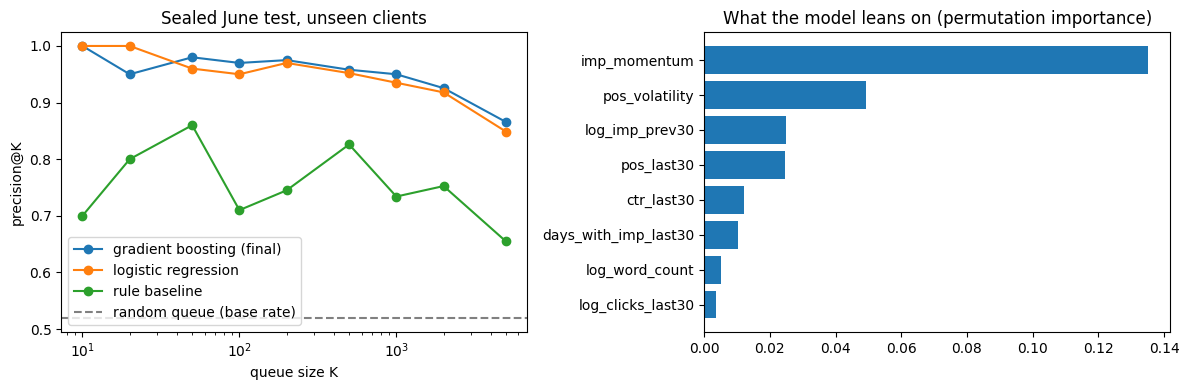

CAPSTONE_JSON {"results": {"dev": {"baseline_rule": {"base_rate": 0.4847, "auc": 0.6139, "ap": 0.5848, "p@20": 0.9, "p@50": 0.86, "p@100": 0.89, "p@500": 0.884, "client_p@10": 0.811, "client_base": 0.498, "clients": 19}, "logreg": {"base_rate": 0.4847, "auc": 0.6961, "ap": 0.6851, "p@20": 0.85, "p@50": 0.9, "p@100": 0.89, "p@500": 0.902, "client_p@10": 0.905, "client_base": 0.498, "clients": 19}, "hgb": {"base_rate": 0.4847, "auc": 0.7311, "ap": 0.7202, "p@20": 0.95, "p@50": 0.96, "p@100": 0.98, "p@500": 0.94, "client_p@10": 0.858, "client_base": 0.498, "clients": 19}}, "sealed": {"baseline_rule": {"base_rate": 0.5186, "auc": 0.6016, "ap": 0.6054, "p@20": 0.8, "p@50": 0.86, "p@100": 0.71, "p@500": 0.826, "client_p@10": 0.746, "client_base": 0.517, "clients": 26}, "logreg": {"base_rate": 0.5186, "auc": 0.701, "ap": 0.7099, "p@20": 1.0, "p@50": 0.96, "p@100": 0.95, "p@500": 0.952, "client_p@10": 0.908, "client_base": 0.517, "clients": 26}, "hgb": {"base_rate": 0.5186, "auc": 0.7023, "ap"

In [8]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
tr = lab[lab.decision_date.isin([T1, T2])]
imp_model = MAKERS[FINAL]().fit(tr[F], tr.declined.astype(int))
sub = sealed_frame.sample(min(20000, len(sealed_frame)), random_state=ff.SEED)
pi = permutation_importance(imp_model, sub[F], sub.declined.astype(int), n_repeats=3, random_state=ff.SEED, scoring='average_precision', n_jobs=-1)
importance = sorted(zip(F, pi.importances_mean.round(4).tolist()), key=lambda x: -x[1])
dv = lab[lab.decision_date.isin(ff.DEV_DATES)]
sig = {}
for col, bins, labels in [('spike_share', [0, .1, .25, .5, 1.0001], ['<10%', '10-25%', '25-50%', '>50%']),
                          ('imp_momentum', [-20, -0.5, -0.15, 0.15, 0.5, 20], ['fell >40%', 'fell 14-40%', 'flat', 'rose 16-65%', 'rose >65%']),
                          ('content_age_days', [90, 180, 270, 365, 10000], ['90-180', '181-270', '271-365', '365+'])]:
    t = dv.groupby(pd.cut(dv[col], bins, labels=labels, include_lowest=True), observed=True).declined.agg(['mean', 'size'])
    sig[col] = [[str(i), round(float(r['mean']), 4), int(r['size'])] for i, r in t.iterrows()]
drift = lab.groupby('decision_date').agg(site_relative=('declined', 'mean'), plain_drop=('declined_abs', 'mean'),
                                         median_site_ratio=('client_ratio', 'median')).round(4).reset_index().values.tolist()
receipt = {'results': out, 'precision_curve_sealed': curves, 'importance_sealed': importance, 'signals_dev': sig,
           'label_drift': drift, 'rows': {k: int(v) for k, v in lab.groupby('decision_date').size().items()},
           'clients': {k: int(v) for k, v in lab.groupby('decision_date').client_hash_id.nunique().items()},
           'deploy_rows': int(len(dep)), 'deploy_sites': int(dep.client_hash_id.nunique()), 'seed': ff.SEED, 'model': FINAL}
json.dump(receipt, open('work/outputs/capstone_metrics.json', 'w'), indent=2, default=str)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for n, lbl in [(FINAL, 'gradient boosting (final)'), ('logreg', 'logistic regression'), ('baseline_rule', 'rule baseline')]:
    ax[0].plot(curves['k'], curves[n], marker='o', label=lbl)
ax[0].axhline(curves['base_rate'], ls='--', c='grey', label='random queue (base rate)'); ax[0].set_xscale('log')
ax[0].set_xlabel('queue size K'); ax[0].set_ylabel('precision@K'); ax[0].legend(); ax[0].set_title('Sealed June test, unseen clients')
names, vals = zip(*importance[:8]); ax[1].barh(names[::-1], vals[::-1]); ax[1].set_title('What the model leans on (permutation importance)')
plt.tight_layout(); plt.show()
print('CAPSTONE_JSON ' + json.dumps(receipt, default=str))

## ML-12: 5-minute demo outline

1. **(0:00-0:45) The problem.** FlyRank's product picks pages to refresh with hand-tuned scores. A content reviewer can't read every page every month. Dashboards show a drop only after it has happened. Question: which pages should they open first?
2. **(0:45-1:45) The trap I hit.** A plain ">20% drop" label climbed from 52% to 75% in three months because whole sites were losing traffic. That's site-wide shock, not something a page refresh fixes. So the label became "fell 20% further than its own site", and its rate stays flat at about 50%.
3. **(1:45-2:45) Method.** 18 signals from the 90 days before decision day (momentum, spikes, position drift, age, depth). A five-sign rule as the baseline. Gradient boosting as the model. Validation is client-grouped *and* time-forward, and June stayed sealed until the end.
4. **(2:45-3:45) One chart, one result.** Show the sealed precision@K curve (model vs rule vs random). On June and on unseen clients: ROC-AUC 0.702 vs 0.602 for the rule. Per-site top-10 precision 0.89 vs 0.75 (random 0.52). And the before/after: a random split looked better than reality (AUC 0.798).
5. **(3:45-4:30) What it says about SEO beliefs.** Momentum and one-day spikes carry the signal. "Old pages decay" points the *other* way once you compare pages with their own site. "Old page-one pages are at risk" showed no difference.
6. **(4:30-5:00) Limits and use.** Observational, one portfolio, a ranking not a probability. A person reviews before anything is touched.

## ML-12: social-post cut

> Which pages will fall behind next month? I trained a model on ~80k pages a month from a real SEO portfolio (FlyRank internship data). Two lessons: (1) a plain "traffic dropped 20%" label mostly measured whole sites falling, so I compared each page with its own site instead; (2) a random train/test split flattered the model. On a sealed month and unseen clients, about 9 of each site's top-10 picks really fell behind, against about 5 by chance. "Old content decays" didn't hold up here. Momentum and one-day spikes did. Paper + code in the link.

## ML-12: 3-sentence employer summary

I built a page-level decline-risk ranker on a real, pseudonymised search warehouse (~79M daily rows; ~70-85k pages per monthly snapshot), with DuckDB aggregation, a leakage-audited feature set and client-grouped, time-forward validation. On a sealed month and clients it never saw, it beat a transparent rule baseline (ROC-AUC 0.702 vs 0.602; per-site top-10 precision 0.89 vs 0.75, random 0.52). Along the way I caught a label that was really measuring portfolio-wide drift, and a leak in my own earlier work, and wrote both up instead of hiding them.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
